In [9]:
import numpy as np

In [12]:
patients = patients.merge(diagnoses, on="DiagnosisID")
patients = patients.merge(outcomes, on="OutcomeID")

In [8]:
patients['AdmissionDate'] = pd.to_datetime(patients['AdmissionDate'])
patients['DischargeDate'] = pd.to_datetime(patients['DischargeDate'])
patients['LengthofStay'] = (patients['DischargeDate'] - patients['AdmissionDate']).dt.days

In [9]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
patients["OutcomeEncoded"] = encoder.fit_transform(patients["OutcomeName"])

In [7]:
patients['OutcomeEncoded'] = patients['OutcomeName'].map({'Recovered': 0, 'Complicated': 1, 'Deceased': 1})

In [11]:
abnormal_conditions = {
    'Blood Sugar' : lambda x : x>120,
    'Cholesterol' : lambda x: x>200,
    'Hemoglobin' : lambda x: x<13
}

def count_abnormal_labs(patient_id):
    patient_labs = labs[labs['PatientID'] == patient_id]
    count = 0
    for test_name, condition in abnormal_conditions.items():
        test_results = patient_labs[patient_labs['TestName'] == test_name]
        count += test_results['Result'].apply(condition).sum()
        return count 
    
    patients['AbnormalLabCount'] = patients['PatientID'].apply(count_abnormal_labs)

In [24]:
patients["HighRisk"] = np.where(
    patients["OutcomeName_x"].isin(["Complicated", "Deceased"]),
    1,
    0
)

In [17]:
patients["HighRisk"].value_counts()


HighRisk
1    163
0     37
Name: count, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split

features = patients[['Age', 'LengthofStay', 'TreatmentCost']]
target = patients['HighRisk']

x_train, x_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

In [14]:
print(patients.columns.tolist())

['PatientID', 'Name', 'Age', 'Gender', 'DiagnosisID', 'AdmissionDate', 'DischargeDate', 'OutcomeID', 'TreatmentCost', 'DiagnosisName_x', 'OutcomeName_x', 'LengthofStay', 'OutcomeEncoded', 'DiagnosisName_y', 'OutcomeName_y']


In [6]:
import pandas as pd
import numpy as np

patients = pd.read_csv("patients.csv")
diagnoses = pd.read_csv("diagnoses.csv")
outcomes = pd.read_csv("outcomes.csv")

In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(features , target , test_size = 0.3 , random_state=42)

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(x_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [23]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(x_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 5  2]
 [15 18]]
              precision    recall  f1-score   support

           0       0.25      0.71      0.37         7
           1       0.90      0.55      0.68        33

    accuracy                           0.57        40
   macro avg       0.57      0.63      0.52        40
weighted avg       0.79      0.57      0.63        40



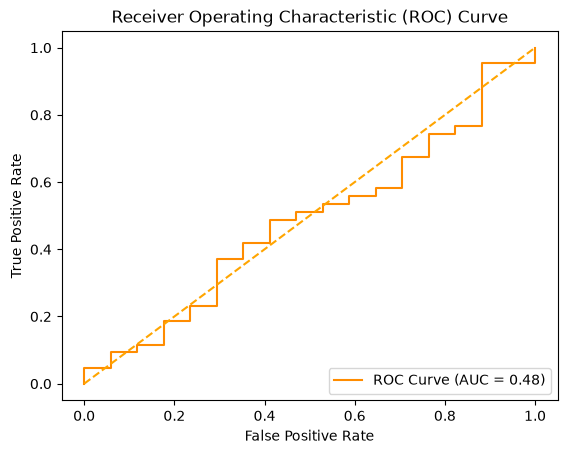

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
y_prob = model.predict_proba(x_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test,y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange',
         label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color = 'orange', linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [21]:
import joblib
joblib.dump(model, 'risk_predict1.ipynb')

['risk_predict1.ipynb']

In [11]:
import streamlit as st
import pandas as pd 
import joblib
model = joblib.load('risk_predict1.ipynb')
st.title("Risk Stratification App")
age = st.number_input("Age", min_value=0)
length_of_stay = st.number_input("Length of Stay (days)", min_value=0)
treatment_cost = st.number_input("Treatment Cost", min_value=0.0)
if st.button('Predict Risk'):
    input_data = pd.DataFrame(
    [[age, length_of_stay, treatment_cost]],
    columns=['Age', 'LengthofStay', 'TreatmentCost']
)
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]
    st.write(f"Risk Prediction: {'High Risk' if prediction ==1 else 'Low Risk'}")
    st.write(f"Risk Probability: {round(probability, 2)}")

2026-07-18 00:27:43.875 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 00:27:43.877 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 00:27:43.879 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 00:27:43.880 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 00:27:43.880 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 00:27:43.881 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 00:27:43.882 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 00:27:43.884 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar